# Balaji Fast Food Sales — Exploratory Data Analysis

**Author:** Aalaa Jandali  
**Dataset:** Balaji Fast Food Sales (Kaggle) — 1,000 orders from an Indian fast-food stall, 2022–2023.

## The business questions
As someone who works front-of-house in a family restaurant, I wanted to answer the questions a real stall owner would ask:

1. **What sells?** Which menu items drive the most revenue?
2. **When do we sell?** Which times of day and days of the week are busiest?
3. **How do people pay?** What's the cash vs. online split?
4. **How is the business trending?** What does monthly revenue look like over time?

## What this notebook shows
Loading a messy CSV → cleaning it → answering each question with a chart → writing down the takeaway. Every step is commented so it's easy to follow.

## 1. Setup
Import the libraries and load the raw file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Chart styling — a clean, consistent look
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
})
ACCENT, DARK, GREY = '#C0392B', '#2C3E50', '#95A5A6'
rupee = FuncFormatter(lambda x, pos: f'\u20b9{int(x):,}')

df = pd.read_csv('../data/Balaji Fast Food Sales.csv')
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (1000, 10)


,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


## 2. First look — what's in the data?
Before cleaning anything, I check the columns, data types, and where values are missing.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.2+ KB


In [3]:
# Where are the gaps?
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

### What I noticed
- **`date`** is stored as text in *two different formats* (`07-03-2022` and `8/23/2022`). I need to parse both.
- **`transaction_type`** (Cash / Online) is missing for **107 rows (~11%)**. I'll keep those as `Unknown` rather than delete them, so I don't throw away the rest of each order's data.
- Everything else looks complete.

## 3. Cleaning
Three steps: parse the mixed date formats, label the missing payments, and add a few helper columns (month, day of week) that make the analysis easier.

In [4]:
def parse_date(s):
    """Handle the two date formats found in the file."""
    s = str(s).strip()
    for fmt in ('%d-%m-%Y', '%m/%d/%Y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df['date'] = df['date'].apply(parse_date)
print('Dates that failed to parse:', df['date'].isna().sum())
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())

Dates that failed to parse: 0
Date range: 2022-01-04 to 2023-12-03


In [5]:
# Keep the missing payments as a labelled category instead of dropping them
df['transaction_type'] = df['transaction_type'].fillna('Unknown')

# Helper columns for the time-based questions
df['month']       = df['date'].dt.to_period('M').astype(str)
df['day_of_week'] = df['date'].dt.day_name()
df['year']        = df['date'].dt.year

df = df.sort_values('date').reset_index(drop=True)
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale,month,day_of_week,year
0,691,2022-01-04,Sandwich,Fastfood,60,7,420,Cash,Mrs.,Evening,2022-01,Tuesday,2022
1,524,2022-01-05,Aalopuri,Fastfood,20,13,260,Online,Mr.,Afternoon,2022-01,Wednesday,2022
2,166,2022-01-06,Panipuri,Fastfood,20,6,120,Cash,Mrs.,Evening,2022-01,Thursday,2022
3,845,2022-01-07,Cold coffee,Beverages,40,6,240,Online,Mrs.,Evening,2022-01,Friday,2022
4,631,2022-01-07,Cold coffee,Beverages,40,13,520,Cash,Mrs.,Evening,2022-01,Friday,2022


## 4. The headline numbers
A quick summary before diving into each question.

In [6]:
total_rev   = df['transaction_amount'].sum()
total_ord   = len(df)
items_sold  = df['quantity'].sum()
avg_order   = df['transaction_amount'].mean()

print(f'Total revenue:      \u20b9{total_rev:,}')
print(f'Total orders:       {total_ord:,}')
print(f'Total items sold:   {items_sold:,}')
print(f'Average order value: \u20b9{avg_order:,.0f}')

Total revenue:      ₹275,230
Total orders:       1,000
Total items sold:   8,162
Average order value: ₹275


## 5. Question 1 — What sells?
Revenue by menu item. I colour the above-median sellers in red so the winners pop.

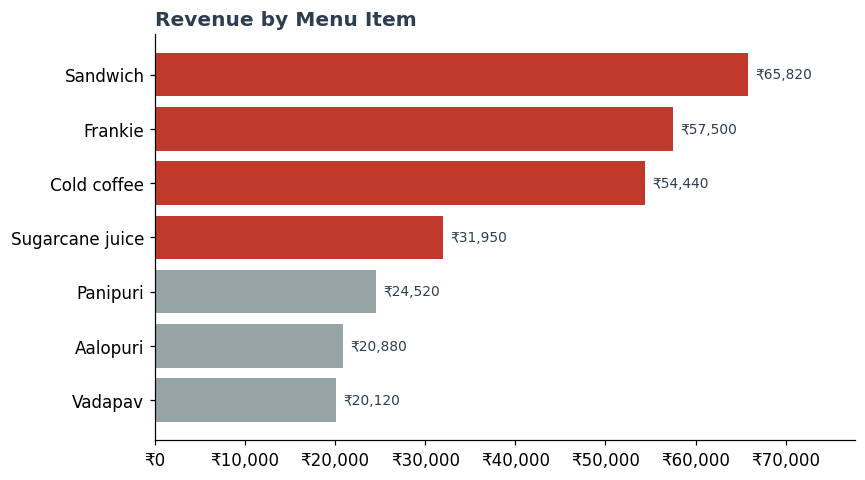

In [7]:
item_rev = df.groupby('item_name')['transaction_amount'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [ACCENT if v >= item_rev.median() else GREY for v in item_rev.values]
ax.barh(item_rev.index, item_rev.values, color=colors)
for i, v in enumerate(item_rev.values):
    ax.text(v + 800, i, f'\u20b9{v:,}', va='center', fontsize=9, color=DARK)
ax.xaxis.set_major_formatter(rupee)
ax.set_xlim(0, item_rev.max() * 1.18)
ax.set_title('Revenue by Menu Item', fontweight='bold', color=DARK, loc='left')
plt.tight_layout(); plt.show()

**Takeaway:** **Sandwich, Frankie, and Cold coffee** are the top three earners and together make up over half of revenue. **Vadapav and Aalopuri** trail well behind. If I ran this stall I'd make sure the top three never run out, and I'd think about whether the bottom items are worth the prep.

## 6. Question 2 — When do we sell?
Two views: time of day, and day of the week.

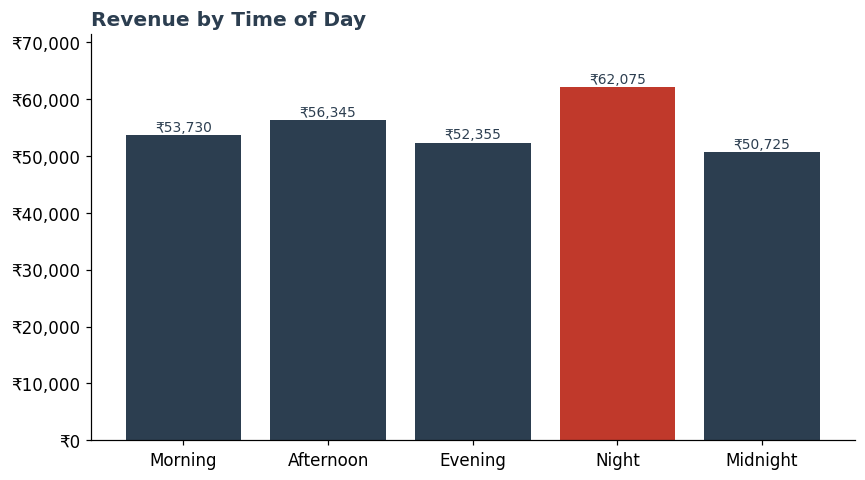

In [8]:
order = ['Morning', 'Afternoon', 'Evening', 'Night', 'Midnight']
tod = df.groupby('time_of_sale')['transaction_amount'].sum().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(tod.index, tod.values, color=DARK)
ax.bar(tod.idxmax(), tod.max(), color=ACCENT)   # highlight the peak
for i, v in enumerate(tod.values):
    ax.text(i, v + 700, f'\u20b9{v:,}', ha='center', fontsize=9, color=DARK)
ax.yaxis.set_major_formatter(rupee)
ax.set_ylim(0, tod.max() * 1.15)
ax.set_title('Revenue by Time of Day', fontweight='bold', color=DARK, loc='left')
plt.tight_layout(); plt.show()

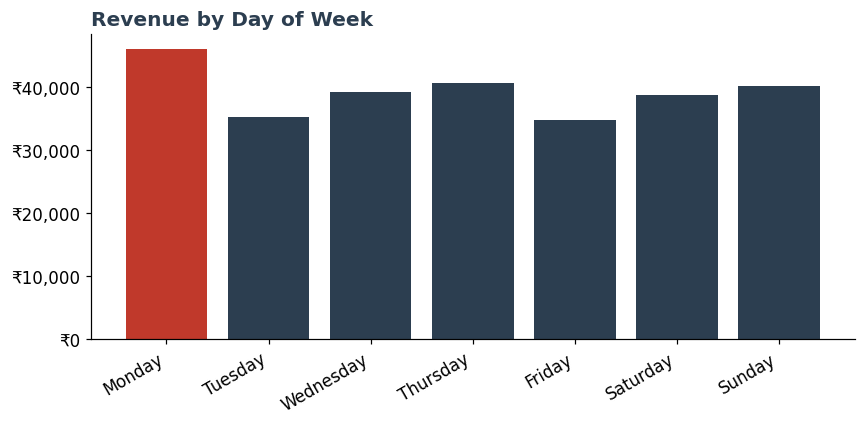

In [9]:
dorder = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week')['transaction_amount'].sum().reindex(dorder)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow.index, dow.values, color=DARK)
ax.bar(dow.idxmax(), dow.max(), color=ACCENT)
ax.yaxis.set_major_formatter(rupee)
ax.set_title('Revenue by Day of Week', fontweight='bold', color=DARK, loc='left')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()

**Takeaway:** Sales are impressively **even across the day** — **Night** is the single best slot but every period pulls its weight, so there's no dead shift to cut. By day, **Monday** is the strongest and the rest of the week is fairly flat. Staffing can stay steady rather than chasing peaks.

## 7. Question 3 — How do people pay?
I only chart the **recorded** payments (excluding the 11% `Unknown`), so the split isn't distorted.

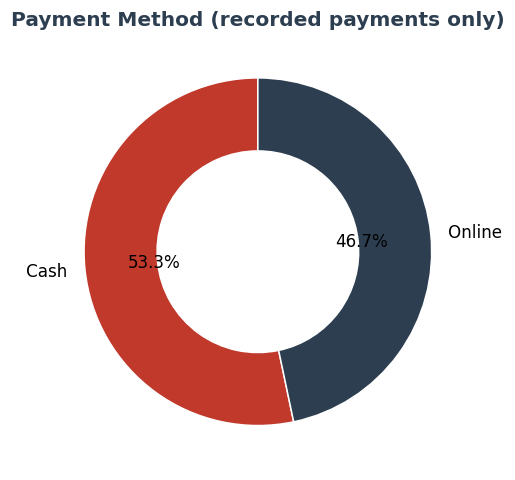

Missing/unknown payment method on 107 of 1000 orders


In [10]:
known = df[df['transaction_type'] != 'Unknown']
pay = known['transaction_type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.pie(pay.values, labels=pay.index, autopct='%1.1f%%',
       colors=[ACCENT, DARK], startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='white'))
ax.set_title('Payment Method (recorded payments only)', fontweight='bold', color=DARK)
plt.tight_layout(); plt.show()

print(f"Missing/unknown payment method on {(df['transaction_type']=='Unknown').sum()} of {len(df)} orders")

**Takeaway:** It's almost a coin flip — roughly **53% cash, 47% online**. Cash is still king but digital is close behind, so the stall needs to keep both options smooth. The **107 missing payment records** are worth flagging to whoever logs the sales: an 11% gap in one field is the kind of thing that quietly breaks reporting later.

## 8. Question 4 — How is the business trending?
Monthly revenue across the full two years.

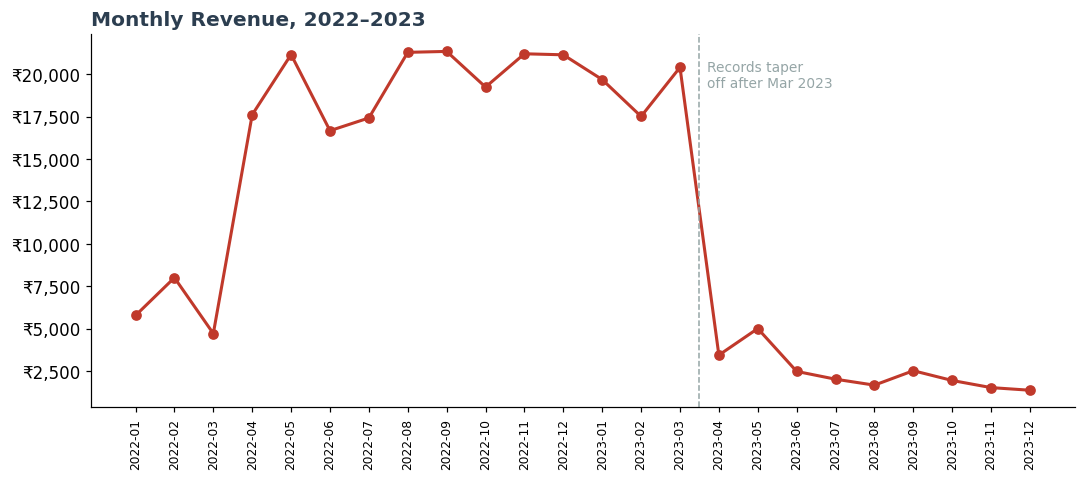

In [11]:
monthly = df.groupby('month')['transaction_amount'].sum()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(len(monthly)), monthly.values, marker='o', color=ACCENT, lw=2)
ax.axvline(14.5, ls='--', color=GREY, lw=1)
ax.text(14.7, monthly.max()*0.9, 'Records taper\noff after Mar 2023', fontsize=9, color=GREY)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=90, fontsize=8)
ax.yaxis.set_major_formatter(rupee)
ax.set_title('Monthly Revenue, 2022–2023', fontweight='bold', color=DARK, loc='left')
plt.tight_layout(); plt.show()

**Takeaway (and an honest caveat):** Through 2022 the stall was steady at roughly **\u20b920,000/month**. From **April 2023** onward the numbers fall off a cliff. 

I don't think sales *actually* collapsed — the much more likely explanation is that **data logging tapered off** (fewer orders recorded, not fewer orders made). Calling this out matters: a good analyst separates *"what the data shows"* from *"what really happened"* instead of reporting a scary 90% drop as fact. For a real business, the action item would be to fix the logging so 2023 can be measured properly.

## 9. Summary of findings

| Question | Finding | Action for the stall |
|---|---|---|
| What sells? | Sandwich, Frankie, Cold coffee lead; Vadapav & Aalopuri lag | Never stock out of the top 3; review the laggards |
| When? | Night is the peak but all times sell well; Monday strongest | Keep staffing steady — no dead shift |
| Payment? | ~53% cash / 47% online | Support both; fix the 11% missing records |
| Trend? | Steady in 2022; records drop after Mar 2023 | Likely a logging gap, not a sales crash — fix data capture |

## What I practiced
Reading a messy CSV, parsing mixed date formats, handling missing values without dropping data, grouping and aggregating with pandas, building clean matplotlib charts, and — most importantly — **turning numbers into plain-language business advice** while being honest about the data's limits.